### Read-in downloaded data

In [1]:
import pandas as pd
import pandas_profiling
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-09-22.csv
2021-09-23.csv
2021-10-01.csv
2021-10-05.csv
2021-10-07.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2021-11-05.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
a3d86f3b-eb45-4641-b05d-30dff7423e6b.csv
res.csv
viewer_lat_long_centroids.csv


In [4]:
data = pd.read_csv("csv/2021-11-05.csv", index_col = False)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21446377 entries, 0 to 21446376
Data columns (total 21 columns):
viewer_id                        object
broadcaster_id                   object
viewer_age                       float64
viewer_gender                    object
viewer_longitude                 float64
viewer_latitude                  float64
viewer_lang                      object
viewer_country                   object
broadcaster_age                  float64
broadcaster_gender               object
broadcaster_longitude            float64
broadcaster_latitude             float64
broadcaster_lang                 object
broadcaster_country              object
duration                         float64
viewer_network                   object
broadcaster_network              object
count                            int64
broadcast_active_viewer_count    object
viewer_lat_long_cluster          int64
rank                             int64
dtypes: float64(7), int64(3), object(11)


In [6]:
data.describe()

,viewer_age,viewer_longitude,viewer_latitude,broadcaster_age,broadcaster_longitude,broadcaster_latitude,duration,count,viewer_lat_long_cluster,rank
count,2.144638e+07,2.144638e+07,2.144638e+07,2.144638e+07,2.144638e+07,2.144638e+07,2.132286e+07,2.144638e+07,2.144638e+07,21446377.0
mean,3.476892e+01,-3.841670e+01,3.118665e+01,3.117435e+01,-4.828111e+01,3.184315e+01,5.182158e+02,2.754313e+00,2.038938e+00,1.0
std,1.013043e+01,7.832797e+01,1.957667e+01,8.271227e+00,7.718859e+01,1.737381e+01,1.586815e+04,9.701030e+01,2.332563e+00,0.0
min,1.800000e+01,-1.781194e+02,-8.124200e+01,1.800000e+01,-1.781194e+02,-5.486670e+01,1.000000e+00,1.000000e+00,0.000000e+00,1.0
25%,2.700000e+01,-9.000000e+01,2.701670e+01,2.500000e+01,-9.470100e+01,2.900000e+01,5.000000e+00,1.000000e+00,0.000000e+00,1.0
50%,3.300000e+01,-7.630000e+01,3.610000e+01,3.000000e+01,-7.920500e+01,3.520000e+01,1.400000e+01,1.000000e+00,2.000000e+00,1.0
75%,4.000000e+01,8.772000e-01,4.199580e+01,3.500000e+01,-3.361000e+00,4.173160e+01,6.000000e+01,1.000000e+00,3.000000e+00,1.0
max,2.000000e+02,1.807650e+02,7.946600e+01,1.240000e+02,1.801962e+02,7.570000e+01,2.212804e+07,2.246760e+05,7.000000e+00,1.0


In [7]:
data.head()

,viewer_id,broadcaster_id,viewer_age,viewer_gender,viewer_longitude,viewer_latitude,viewer_lang,viewer_country,broadcaster_age,broadcaster_gender,...,broadcaster_latitude,broadcaster_lang,broadcaster_country,duration,viewer_network,broadcaster_network,count,broadcast_active_viewer_count,viewer_lat_long_cluster,rank
0,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,c3 cc 0e 57 fc 88 05 2c 37 f0 11 29 11 d2 cf 96,45.0,male,121.598999,24.978001,zh,TW,36.0,female,...,25.000000,zh,TW,18946.0,skout,skout,178,"2021-11-01:17,2021-11-01:14,2021-11-01:13,2021...",6,1
1,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,b9 86 e7 54 8a 49 ee 24 89 56 5f 85 ed be a8 93,45.0,male,122.598999,23.978001,zh,TW,22.0,female,...,24.668000,zh,US,536.0,skout,meetme,16,"2021-11-01:25,2021-11-01:22",6,1
2,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,5a db 06 50 b6 21 6b 02 95 4e f1 66 3b 84 9b 99,45.0,male,122.598999,24.978001,zh,TW,36.0,female,...,25.073999,zh,TW,104.0,skout,skout,8,"2021-11-01:37,2021-11-01:18,2021-11-01:35",6,1
3,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,20 77 88 2b be 46 f1 f7 13 8d fa ec 34 98 e8 55,45.0,male,121.598999,24.978001,zh,TW,33.0,female,...,25.056999,zh,TW,1740.0,skout,skout,9,"2021-11-01:26,2021-11-01:24,2021-11-01:18",6,1
4,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,7d 0e 4a 54 10 b4 f8 b1 b6 1d 3f cd 21 90 43 16,45.0,male,121.598999,24.978001,zh,TW,25.0,male,...,26.084000,zh,TW,220.0,skout,skout,16,2021-11-01:2,6,1


In [8]:
data['viewer_id'].nunique()

1546839

In [9]:
data['broadcaster_id'].nunique()

138139

### Preprocessing data

In [92]:
df = data.copy()

In [93]:
df.drop(labels=['rank'], axis=1,inplace=True)

In [94]:
len(df[df.isnull().any(axis=1)])/df.shape[0]

0.1045163945406723

In [95]:
df.dropna(inplace=True)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19204879 entries, 0 to 21446375
Data columns (total 20 columns):
viewer_id                        object
broadcaster_id                   object
viewer_age                       float64
viewer_gender                    object
viewer_longitude                 float64
viewer_latitude                  float64
viewer_lang                      object
viewer_country                   object
broadcaster_age                  float64
broadcaster_gender               object
broadcaster_longitude            float64
broadcaster_latitude             float64
broadcaster_lang                 object
broadcaster_country              object
duration                         float64
viewer_network                   object
broadcaster_network              object
count                            int64
broadcast_active_viewer_count    object
viewer_lat_long_cluster          int64
dtypes: float64(7), int64(2), object(11)
memory usage: 3.0+ GB


In [97]:
df['viewer_id'].nunique()

1481885

In [98]:
df['broadcaster_id'].nunique()

105944

In [99]:
df.groupby(['viewer_network'])['broadcaster_id'].nunique()

viewer_network
meetme    95164
pof       74969
skout     88898
zoosk     34339
Name: broadcaster_id, dtype: int64

In [100]:
df.groupby(['viewer_network'])['broadcaster_id'].nunique()/sum(df.groupby(['viewer_network'])['broadcaster_id'].nunique())

viewer_network
meetme    0.324382
pof       0.255544
skout     0.303023
zoosk     0.117050
Name: broadcaster_id, dtype: float64

#### generate age bucket

In [101]:
def age_bucket(age):
    # min(age) = 18
    if age < 25:
        return 0
    elif age < 30:
        return 1
    elif age < 35:
        return 2
    elif age < 40:
        return 3
    elif age < 45:
        return 4
    elif age < 50:
        return 5
    elif age < 55:
        return 6
    elif age < 60:
        return 7
    elif age < 65:
        return 8
    else:
        return 9

In [102]:
df['viewer_age_bucket'] = df['viewer_age'].apply(lambda x: age_bucket(x))

#### drop outliers

In [103]:
df['duration'].quantile(.99)

8169.0

In [104]:
df = df[df['duration'] < df['duration'].quantile(.99)]

In [119]:
res = df.groupby(['broadcaster_id'])['viewer_id'].size().to_frame('size').reset_index()

In [121]:
valid_broadcasters = set(res.loc[res['size'] > 1]['broadcaster_id'])

In [128]:
df = df[df['broadcaster_id'].map(lambda x: x in valid_broadcasters)]

In [129]:
FEATURES = [
    'broadcaster_id',
    'viewer_network',
    'viewer_age_bucket',
    'viewer_gender',
    'viewer_lang', 
    'viewer_country',
    'viewer_lat_long_cluster',
]

In [130]:
df_agg = df.groupby(FEATURES).agg({'duration': np.mean, 'viewer_id': np.size, 'count': np.mean})

In [131]:
df_agg = df_agg.reset_index()

In [132]:
df_agg = df_agg.rename(columns={'viewer_id': 'weight', 'count':'avg_cnt'})

In [133]:
df_agg.describe(percentiles=np.linspace(0, 1, 11))

,viewer_age_bucket,viewer_lat_long_cluster,duration,weight,avg_cnt
count,4.626786e+06,4.626786e+06,4.626786e+06,4.626786e+06,4.626786e+06
mean,2.888512e+00,2.705083e+00,1.499988e+02,4.107062e+00,1.995614e+00
std,2.225554e+00,2.426335e+00,4.947043e+02,1.391015e+01,6.021271e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
0%,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
10%,0.000000e+00,0.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00
20%,1.000000e+00,0.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00
30%,1.000000e+00,0.000000e+00,8.000000e+00,1.000000e+00,1.000000e+00
40%,2.000000e+00,2.000000e+00,1.300000e+01,1.000000e+00,1.000000e+00
50%,2.000000e+00,2.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00


In [134]:
df_agg['log_duration'] = df_agg['duration'].apply(lambda x: np.log(x))

In [135]:
df_agg.describe(percentiles=np.linspace(0, 1, 11))

,viewer_age_bucket,viewer_lat_long_cluster,duration,weight,avg_cnt,log_duration
count,4.626786e+06,4.626786e+06,4.626786e+06,4.626786e+06,4.626786e+06,4.626786e+06
mean,2.888512e+00,2.705083e+00,1.499988e+02,4.107062e+00,1.995614e+00,3.232025e+00
std,2.225554e+00,2.426335e+00,4.947043e+02,1.391015e+01,6.021271e+00,1.797586e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
0%,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
10%,0.000000e+00,0.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.098612e+00
20%,1.000000e+00,0.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,1.609438e+00
30%,1.000000e+00,0.000000e+00,8.000000e+00,1.000000e+00,1.000000e+00,2.079442e+00
40%,2.000000e+00,2.000000e+00,1.300000e+01,1.000000e+00,1.000000e+00,2.564949e+00
50%,2.000000e+00,2.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,3.044522e+00


In [136]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

<AxesSubplot:ylabel='Frequency'>

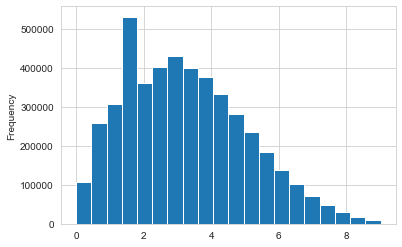

In [137]:
df_agg['log_duration'].plot(kind='hist', bins=20)

In [138]:
df_agg.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,duration,weight,avg_cnt,log_duration
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,962.000,2,4.000,6.869014
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,204.400,5,1.600,5.320079
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,female,es,US,0,165.000,1,1.000,5.105945
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,614.750,4,3.750,6.421216
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,511.625,8,2.875,6.237592


### Lightgbm Model

In [139]:
from typing import Dict, Iterable, Tuple
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

In [140]:
def split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """return distinct train and test sets"""
    return train_test_split(df, random_state=0, test_size=0.3)

In [141]:
def decompose(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """break down data into features, labels and weights"""
    return df.drop(['y', 'w'], axis=1), df.y, df.w

In [142]:
def ungroup(X: pd.DataFrame, w: pd.DataFrame) -> pd.DataFrame:
    """expand all repeated columns"""
    return X.reindex(X.index.repeat(w))

In [143]:
def group(X: pd.DataFrame) -> pd.DataFrame:
    """append weight to pandas dataframe by groupby all columns"""
    return X.groupby(list(X.columns)).size().to_frame('w').reset_index()

In [144]:
def get_feature_mappings(X: pd.DataFrame) -> Dict[str, Dict[str, int]]:
    """map of value to pandas category"""
    return {
        f: {str(x): i
            for i, x in enumerate(X[f].cat.categories, start=1)}
        for f in X
    }

In [145]:
def etl(X: pd.DataFrame,
        y: pd.Series,
        w: pd.Series = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """transform the data"""
    X = X.assign(y=y)
    if w is not None:
        X_train, X_test = split(ungroup(X, w))
        return group(X_train), group(X_test)
    else:
        X['w'] = 1
        return split(X)

In [146]:
def predict(model: lgb.Booster,
            X: pd.DataFrame,
            regression: bool = False) -> pd.Series:
    """prediction wrapper"""
    return model.predict(X) if regression else model.predict_proba(X)[:, 1]

In [147]:
def evaluate(X: pd.DataFrame,
             y: pd.Series,
             w: pd.Series,
             y_pred: pd.Series,
             regression: bool = False) -> Dict[str, any]:
    """calculate evaluation metrics"""
    metrics = {'records': str(len(y)), 'weights': str(sum(w))}
    metrics['raw_accuracy'] = prediction_metrics(y, y_pred, weights=w)
    if not regression:
        metrics['log_loss'] = log_loss(y, y_pred, sample_weight=w)
        metrics['roc_auc_score'] = roc_auc_score(y, y_pred, sample_weight=w)
    return metrics

In [148]:
from sklearn import metrics
def prediction_metrics(var_y, var_y_pred, weights=None):
    if weights is None:
        weights = np.ones(len(var_y))
    avg = np.average(var_y, weights=weights)
    pred_avg = np.average(var_y_pred, weights=weights)
    bias2 = np.average(var_y - var_y_pred, weights=weights) ** 2
    var = np.average(var_y_pred ** 2, weights=weights) - np.average(var_y_pred, weights=weights) ** 2
    square_error = metrics.mean_squared_error(var_y, var_y_pred, weights)
    abs_err = metrics.mean_absolute_error(var_y, var_y_pred, weights)
    r2_score = metrics.r2_score(var_y, var_y_pred, weights)
    return dict(avg=avg, pred_avg=pred_avg, bias2=bias2, var=var, square_error=square_error, abs_err=abs_err, abs_err_ratio=abs_err / avg, r2_score=r2_score)

In [149]:
def build_model(
    X: pd.DataFrame,
    y: pd.Series,
    w: pd.Series = None,
    categories: Iterable[str] = [],
    unencoded_categories: Iterable[str] = [],
    params: Dict[str, any] = {},
    regression: bool = False
) -> Tuple[lgb.LGBMModel, Dict[str, any], pd.DataFrame, pd.DataFrame]:
    """take the sql data and output model and metadata"""
    X[unencoded_categories] = X[unencoded_categories].astype('category')
    metadata = {
        'model_type': 'lightgbm',
        'features': list(X),
        'category_features': categories,
        'mappings': get_feature_mappings(X[unencoded_categories]),
    }

    train_df, test_df = etl(X, y, w)
    X, y, w = decompose(train_df)
    
    model = (lgb.LGBMRegressor if regression else lgb.LGBMClassifier)(random_state=0, **params)
    model.fit(X, y, w, categorical_feature=categories)
    train_df['y_pred'] = predict(model, X, regression)
    
    metadata['train_accuracy'] = evaluate(X, y, w, train_df['y_pred'], regression)
    metadata['train_accuracy']['data_type'] = 'train'
    
    X, y, w = decompose(test_df)
    test_df['y_pred'] = predict(model, X, regression)
    metadata['test_accuracy'] = evaluate(X, y, w, test_df['y_pred'], regression)
    metadata['test_accuracy']['data_type'] = 'test'
    return model, metadata, train_df, test_df

In [160]:
pred_model, pred_metadata, train_df, test_df = build_model(
    X=df_agg[FEATURES],
    y=df_agg['log_duration'],
    w=df_agg['weight'],
    categories=FEATURES,
    unencoded_categories=FEATURES,
    params={'n_estimators': 300, 'num_leaves': 300, "learning_rate": 0.1, 'max_bin': 100},
    regression=True
)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/pandas/core/frame.py:3509: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/lightgbm/basic.py:1551: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/sklearn/utils/validation.py:72: FutureWarning: Pass sample_weight=0          1
1          4
2          2
3          7
4          1
          ..
3737951    3
3737952    1
3737953    1
3737954    1
3737955    1
Name: w, Length: 3737956, dtype: int64 as keyword args. From version 1.0 (renaming of 0.25) pa

In [161]:
pred_metadata['train_accuracy']

{'records': '3737956',
 'weights': '13301748',
 'raw_accuracy': {'avg': 4.210331779673317,
  'pred_avg': 4.210337474644581,
  'bias2': 3.24326977264227e-11,
  'var': 0.7070134238308832,
  'square_error': 1.201323800542436,
  'abs_err': 0.7621083722276892,
  'abs_err_ratio': 0.18100910144587745,
  'r2_score': 0.4257377073109143},
 'data_type': 'train'}

In [162]:
pred_metadata['test_accuracy']

{'records': '2191489',
 'weights': '5700750',
 'raw_accuracy': {'avg': 4.210467854485196,
  'pred_avg': 4.212315131238741,
  'bias2': 3.4124314041924282e-06,
  'var': 0.6961994985936144,
  'square_error': 1.2716188978345417,
  'abs_err': 0.7833325616873347,
  'abs_err_ratio': 0.18604406654070296,
  'r2_score': 0.3922878044973652},
 'data_type': 'test'}

In [163]:
train_df.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,y,w,y_pred
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,6.869014,1,4.374003
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,5.320079,4,4.632830
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,6.421216,2,4.729799
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,6.237592,7,4.626268
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,4,male,en,US,0,5.609472,1,4.438909


In [164]:
train_df['y_pred_binned'] = pd.qcut(train_df['y_pred'], q=10)

In [165]:
train_df['y_pred_binned'].value_counts()

(3.886, 4.099]     383736
(3.414, 3.648]     374848
(4.656, 8.503]     373796
(3.164, 3.414]     373796
(2.495, 2.886]     373796
(-0.504, 2.495]    373796
(4.375, 4.656]     373795
(2.886, 3.164]     373795
(3.648, 3.886]     372743
(4.099, 4.375]     363855
Name: y_pred_binned, dtype: int64

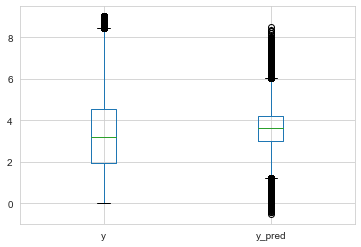

In [166]:
plt.figure()
boxplot = train_df.boxplot(column=['y', 'y_pred'])

In [167]:
def cnt_distinct(x):
    return len(set(x))

In [168]:
train_df.groupby(['y_pred_binned']).agg({'broadcaster_id': cnt_distinct, 'y':np.mean, 'y': np.mean, 'y_pred': np.mean})

,broadcaster_id,y,y_pred
y_pred_binned,,,
"(-0.504, 2.495]",27382,1.927334,2.084657
"(2.495, 2.886]",42600,2.467812,2.706743
"(2.886, 3.164]",51842,2.769865,3.029330
"(3.164, 3.414]",55028,2.998939,3.293621
"(3.414, 3.648]",61258,3.199181,3.531390
"(3.648, 3.886]",65842,3.403618,3.763431
"(3.886, 4.099]",73972,3.574634,4.007581
"(4.099, 4.375]",71026,3.882655,4.238543
"(4.375, 4.656]",72456,4.116838,4.520286


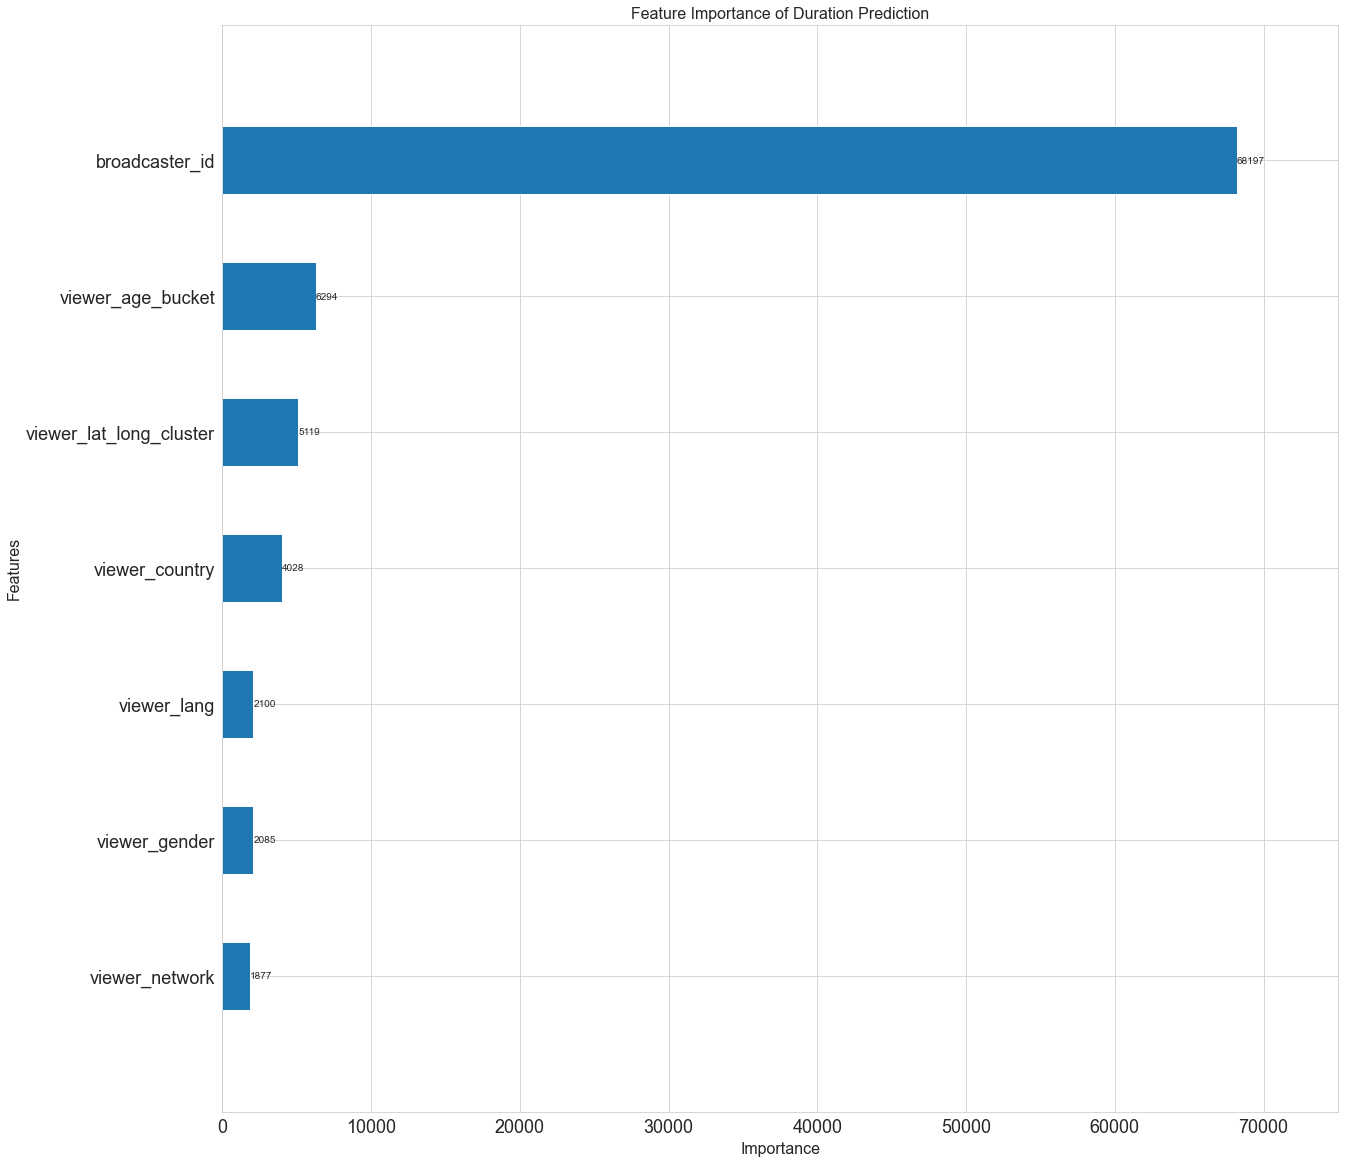

In [169]:
lgb.plot_importance(pred_model, figsize=(20,20), height=0.5)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title("Feature Importance of Duration Prediction", fontsize=16)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.show()